In [21]:
import pandas as pd

In [22]:
df =pd.read_csv('D:\\EduNet\\NSTI_Indore25_26\\ML\\Datasets\\burger_buy_dataset.csv')
df

,Age,Is_Student,Has_Coupon,Income,Visit_Frequency,Buys_Burger
0,54,0,0,16.84,1,0
1,44,0,0,56.75,4,0
2,30,0,1,22.67,7,1
3,58,0,0,63.55,7,0
4,23,1,1,23.13,2,1
...,...,...,...,...,...,...
295,22,1,0,73.13,5,1
296,18,1,1,69.97,1,0
297,32,0,1,16.31,6,1
298,48,0,0,21.84,7,0


In [23]:
df.columns

Index(['Age', 'Is_Student', 'Has_Coupon', 'Income', 'Visit_Frequency',
       'Buys_Burger'],
      dtype='object')

In [24]:
X = df[['Age', 'Is_Student', 'Has_Coupon', 'Income', 'Visit_Frequency']]
X

,Age,Is_Student,Has_Coupon,Income,Visit_Frequency
0,54,0,0,16.84,1
1,44,0,0,56.75,4
2,30,0,1,22.67,7
3,58,0,0,63.55,7
4,23,1,1,23.13,2
...,...,...,...,...,...
295,22,1,0,73.13,5
296,18,1,1,69.97,1
297,32,0,1,16.31,6
298,48,0,0,21.84,7


In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA(n_components=2)
data = pca.fit_transform(X)
data

array([[-2.61595268e+01,  1.05025138e+01],
       [ 1.49457079e+01,  9.99690180e+00],
       [-1.50404100e+01, -1.13957366e+01],
       [ 1.83189477e+01,  2.52320928e+01],
       [-1.29279979e+01, -1.82128695e+01],
       [ 1.91745251e+01,  2.82215249e+00],
       [-4.04824239e+00,  1.57443241e+01],
       [-2.41319898e+01, -9.47473604e+00],
       [-1.52106266e+01, -3.26093715e+00],
       [ 2.21636401e+01, -6.82572958e+00],
       [ 9.30397056e+00, -9.77958239e+00],
       [-1.33553723e+00,  9.80001894e-01],
       [-3.53539822e+01,  5.37575864e+00],
       [ 1.63489217e+01,  2.17269741e+01],
       [ 2.71110745e+01,  7.71323542e+00],
       [ 2.93013856e+01, -1.34203350e+01],
       [-8.72181287e+00, -2.79908219e+00],
       [ 1.04117059e+01, -1.87837126e+01],
       [ 6.98459040e+00,  2.96237308e+00],
       [-2.71057227e+01,  1.54977418e+01],
       [ 1.00981587e+00,  7.81598349e+00],
       [ 1.22607186e+01,  1.85262439e+01],
       [ 1.60092116e+01, -1.75052740e+01],
       [-1.

In [27]:
dataFrame = pd.DataFrame(data,columns=['a','b'])
dataFrame

,a,b
0,-26.159527,10.502514
1,14.945708,9.996902
2,-15.040410,-11.395737
3,18.318948,25.232093
4,-12.927998,-18.212869
...,...,...
295,35.931378,-7.647336
296,33.816381,-12.334150
297,-21.678654,-10.929161
298,-19.979565,5.921946


In [28]:
import matplotlib.pyplot as plt

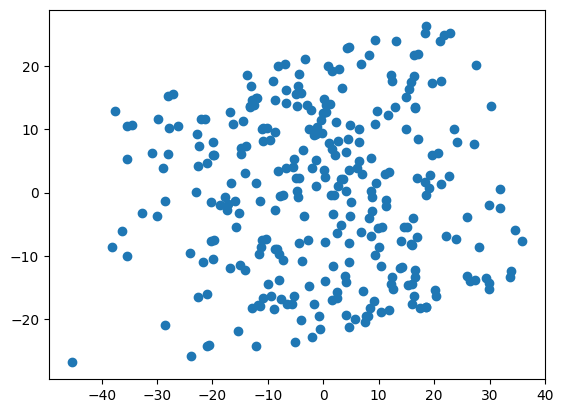

In [29]:
plt.scatter(dataFrame['a'],dataFrame['b'])

In [30]:
from sklearn.cluster import KMeans

In [31]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i)
    model.fit(dataFrame)
    wcss.append(model.inertia_)
wcss

[127993.01635800913,
 75849.86539553195,
 50870.24080253512,
 38747.28398029856,
 29441.894278544074,
 25165.441420962004,
 22048.296027681557,
 18892.53562758892,
 16617.398171418496,
 14570.230290633086]

([<matplotlib.axis.YTick at 0x1ed95ca9670>,
 [Text(0, 127993.01635800913, '127993'),
  Text(0, 75849.86539553195, '75850'),
  Text(0, 50870.24080253512, '50870'),
  Text(0, 38747.28398029856, '38747'),
  Text(0, 29441.894278544074, '29442'),
  Text(0, 25165.441420962004, '25165'),
  Text(0, 22048.296027681557, '22048'),
  Text(0, 18892.53562758892, '18893'),
  Text(0, 16617.398171418496, '16617'),
  Text(0, 14570.230290633086, '14570')])

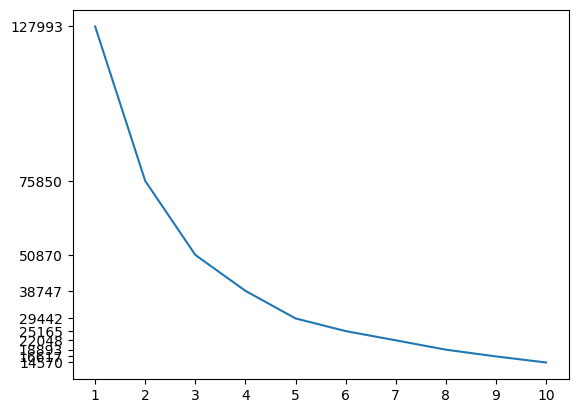

In [32]:
clusters = [1,2,3,4,5,6,7,8,9,10]
plt.plot(clusters,wcss)
plt.xticks(clusters)
plt.yticks(wcss)

In [33]:
model = KMeans(n_clusters=5)
model.fit(dataFrame)

KMeans(n_clusters=5)

In [36]:
X['Group'] = model.predict(dataFrame)
X

,Age,Is_Student,Has_Coupon,Income,Visit_Frequency,Group
0,54,0,0,16.84,1,1
1,44,0,0,56.75,4,3
2,30,0,1,22.67,7,2
3,58,0,0,63.55,7,3
4,23,1,1,23.13,2,2
...,...,...,...,...,...,...
295,22,1,0,73.13,5,0
296,18,1,1,69.97,1,0
297,32,0,1,16.31,6,2
298,48,0,0,21.84,7,1


In [37]:
X['Group'].unique()

array([1, 3, 2, 4, 0])

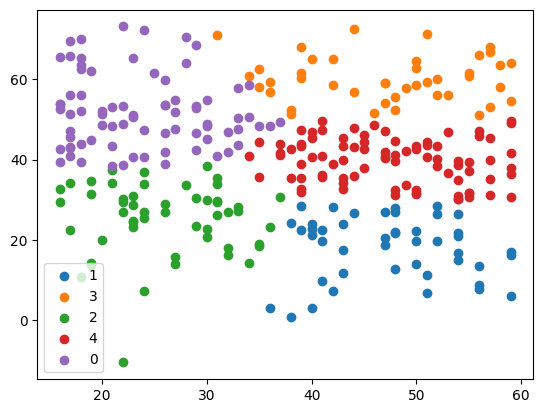

In [38]:
for i in X['Group'].unique():
    newDF = X[X['Group'] == i]
    plt.scatter(newDF['Age'],newDF['Income'],label = i)
plt.legend()
plt.show()